# Regression, part a - Mikaela

In [ ]:
import pandas as pd

file_path = "student_lifestyle_dataset_full..csv" 
df = pd.read_csv(file_path)

numeric_df = df.select_dtypes(include=['float64', 'int64'])
categorical_df = df.select_dtypes(include=['object'])

ranges = numeric_df.max() - numeric_df.min()
std_devs = numeric_df.std()
means = numeric_df.mean()

stats_summary = pd.DataFrame({
    "Min": numeric_df.min(),
    "Max": numeric_df.max(),
    "Range": ranges,
    "Mean": means,
    "Standard Deviation": std_devs
})

print("=== Range and Standard Deviation of Numeric Attributes ===")
print(stats_summary)

print("\n=== Frequency counts of Categorical Attributes ===")
for col in categorical_df.columns:
    print(f"\n{col}:")
    counts = categorical_df[col].value_counts()
    print(dict(counts))

=== Range and Standard Deviation of Numeric Attributes ===
                                 Min     Max   Range         Mean  \
Student_ID                       1.0  2000.0  1999.0  1000.500000   
Study_Hours_Per_Day              5.0    10.0     5.0     7.475800   
Extracurricular_Hours_Per_Day    0.0     4.0     4.0     1.990100   
Sleep_Hours_Per_Day              5.0    10.0     5.0     7.501250   
Social_Hours_Per_Day             0.0     6.0     6.0     2.704550   
Physical_Activity_Hours_Per_Day  0.0    13.0    13.0     4.328300   
Grades                           5.6    10.0     4.4     7.789825   

                                 Standard Deviation  
Student_ID                               577.494589  
Study_Hours_Per_Day                        1.423888  
Extracurricular_Hours_Per_Day              1.155855  
Sleep_Hours_Per_Day                        1.460949  
Social_Hours_Per_Day                       1.688514  
Physical_Activity_Hours_Per_Day            2.514110  
Grades    

Best λ:  3.3033702702702707


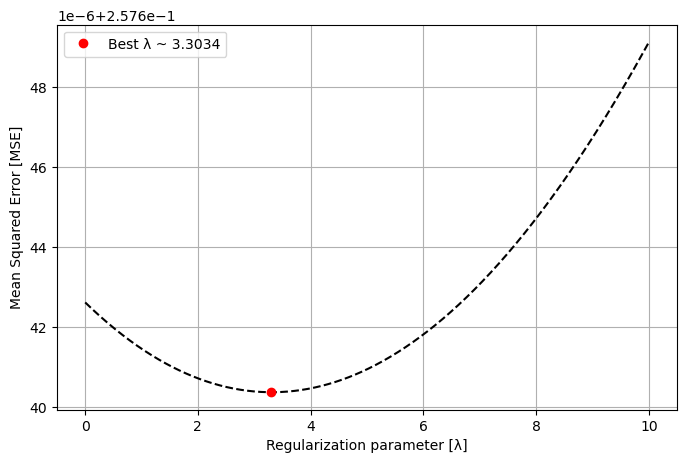


Coefficients: 
Study_Hours              :  0.475
Extracurricular_Hours    : -0.080
Sleep_Hours              : -0.089
Social_Hours             : -0.080
Physical_Activity_Hours  : -0.127
Gender                   : -0.009
Stress_Level             :  0.002
Intercept:  7.7898249999999996


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Project02 - Part A - Linear Regression 

df = pd.read_csv('student_lifestyle_dataset_full..csv')

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Stress_Level'] = df['Stress_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})

X = df[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day',
'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Gender', 'Stress_Level']].values
y = df['Grades'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge Regression with cross validation to find best λ
lambdas = np.linspace(0.0001, 10, 1000)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

for lam in lambdas:
    fold_errors = []
    for train_idx, test_idx in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = Ridge(alpha=lam)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        fold_errors.append(mean_squared_error(y_test, y_pred))
    mse_scores.append(np.mean(fold_errors))

best_lambda = lambdas[np.argmin(mse_scores)]
print('Best λ: ', best_lambda)

plt.figure(figsize=(8,5))
plt.plot(lambdas, mse_scores, 'k--')
plt.plot([best_lambda],[min(mse_scores)], 'ro', label='Best λ ~ {:.4f}'.format(best_lambda))
plt.xlabel('Regularization parameter [λ]')
plt.ylabel('Mean Squared Error [MSE]')
plt.grid(True) ; plt.legend()
plt.savefig('project02_partA2.png')
plt.show()

best_model = Ridge(alpha=best_lambda)
best_model.fit(X_scaled, y)

feature_names = ['Study_Hours', 'Extracurricular_Hours', 'Sleep_Hours',
                 'Social_Hours', 'Physical_Activity_Hours', 'Gender', 'Stress_Level']

print('\nCoefficients: ')
for name, coef in zip(feature_names, best_model.coef_):
    print(f"{name:25s}: {coef: .3f}")

print('Intercept: ', best_model.intercept_)
